<a href="https://colab.research.google.com/github/ashisrivastavaa/Learning-ML/blob/main/Linear_Regression_Multiple_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression #to generate some dummy data
plt.style.use("seaborn-v0_8")

In [137]:
#Generate the data
X,y=make_regression(n_samples=500,n_features=10,n_informative=5,noise=28.8,random_state=0)
print(X.shape,y.shape)
n_features=X.shape[1]


(500, 10) (500,)


In [138]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9
0,1.706468,1.511639,-0.000417,0.374155,0.073285,0.701783,0.409552,-0.461894,-0.626490,-0.799593
1,-1.616956,0.640132,-0.369182,-0.239379,-0.738031,-0.024326,1.099660,0.279925,-0.098150,0.655264
2,0.093953,-0.130107,0.929505,0.582225,-2.739677,0.943046,-2.094603,-0.569312,0.269904,0.123722
3,-1.542758,-0.789954,0.537035,-0.286835,-2.369623,-0.767332,1.634406,-0.260560,0.128957,0.571227
4,-0.101003,-2.231538,0.436187,1.571463,1.324868,-0.587375,1.077315,0.840648,0.261106,0.811090


In [139]:
#Normalise this data ->want mean for each column
#if axis is 0 it iterate over rows and if axis is 1 it iterate over columns
def Normalise(X):
  u=X.mean(axis=0)
  std=X.std(axis=0)
  return (X-u)/std #formula for standardization of data



In [140]:
X=Normalise(X)
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9
0,1.764831,1.579606,0.093808,0.341546,0.103202,0.745205,0.421736,-0.461091,-0.710885,-0.761760
1,-1.612963,0.709920,-0.277540,-0.301827,-0.693297,-0.045695,1.116862,0.265971,-0.166048,0.714702
2,0.125936,-0.058708,1.030243,0.559735,-2.658385,1.007996,-2.100631,-0.566372,0.213499,0.175267
3,-1.537551,-0.717175,0.635024,-0.351591,-2.295090,-0.855000,1.655498,-0.263762,0.068151,0.629417
4,-0.072209,-2.155744,0.533470,1.597083,1.331926,-0.658985,1.094355,0.815541,0.204426,0.872842


In [141]:
X.mean(axis=0)

array([-2.75335310e-17,  5.82867088e-17, -1.06581410e-17, -1.39888101e-17,
        2.49800181e-18,  4.28546088e-17,  1.43635104e-17,  1.46549439e-17,
        7.14983628e-17, -1.07691633e-16])

In [142]:
X.std(axis=0) #it is close to 1 for each feature

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

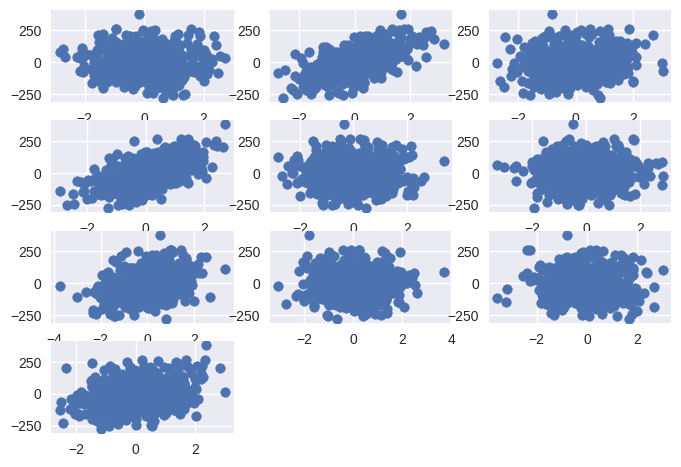

In [143]:
#Visualise y as function of each feature
for f in range(0,10):#10 is not included
  plt.subplot(4,3,f+1) #divide drawing regions in 4x3 # the subplot id start with 1 thats why f+1
  plt.scatter(X[:,f],y)#from the x matrix the fth column followed by y that we got
plt.show()



In [144]:
# Train Test Split
XTrains, XTests, YTrains, YTests = train_test_split(X, y, test_size=0.3, random_state=0, shuffle=False) #order should be maintained

In [145]:
print(XTrains.shape,YTrains.shape)
print(XTests.shape,YTests.shape)

(350, 10) (350,)
(150, 10) (150,)


In [146]:
def preprocess(X):
  #add a column of 1s in X as 0th column
  if X.shape[1]==n_features:
    m=X.shape[0]
    ones=np.ones((m,1))
    X=np.hstack((ones,X)) #stacks ones and X horizontally
  return X

In [147]:
#Modeling /Linear Regression with Multiple Features
def hypothesis(X,theta):
  return np.dot(X,theta)# it is vectorise and faster way than the loops

#Loss function
def loss(X,y,theta):
  yp=hypothesis(X,theta)
  error=np.mean((yp-y)**2)
  return error

def Gradient(X,y,theta):
  yp=hypothesis(X,theta)
  grad=np.dot(X.T,(yp-y))
  m=X.shape[0]
  return grad/m


def train(X,y,lr=0.1,max_itr=100):
  n=X.shape[1]
  theta=np.random.randn(n)
  error_list=[]

  for i in range(max_itr):
    e=loss(X,y,theta)
    error_list.append(e)
    grad=Gradient(X,y,theta)
    theta=theta-lr*grad
  plt.plot(error_list)
  return theta,error_list



[-0.49846249 62.08405306 11.08945117 65.80920583 -0.54673368  0.6412023
 41.07921926  0.45218262  0.68546967 22.25330188]


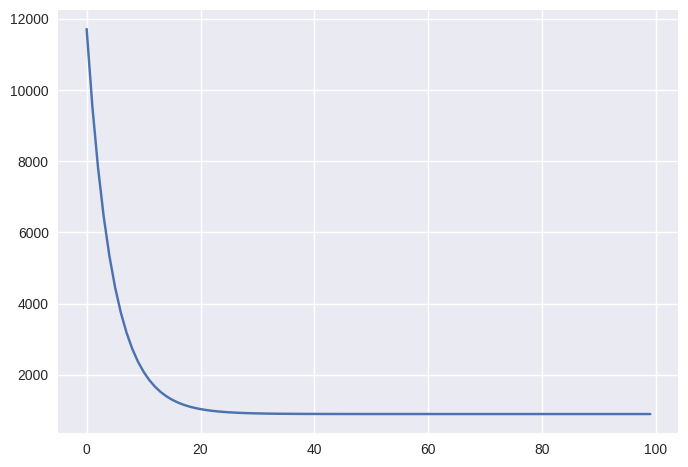

In [148]:
theta, error_list = train(XTrains, YTrains)
print(theta)

In [149]:
#Evaluation->R2 Score
def r2score(y, yp):
    ymean = y.mean()
    num = np.sum((y - yp)**2)
    den = np.sum((y - ymean)**2)
    return 1 - (num / den)


In [150]:
yp=hypothesis(XTests,theta)
print(r2score(YTests,yp))

0.9197225712396995


In [151]:
##Linear Regression with SK-Learn
from sklearn.linear_model import LinearRegression

In [152]:
model=LinearRegression()
model.fit(XTrains,YTrains) #train the model

LinearRegression()

In [153]:
yp=model.predict(XTests)

In [154]:
yp.shape

(150,)

In [155]:
model.score(XTests,YTests)  # same result as we done earlier using r2 score formula


0.9166551886234193

In [156]:
model.intercept_ #intercept use for theta0

np.float64(-5.32584071439109)

In [157]:
model.coef_ #coe use for other theta expect theta0

array([-0.29688749, 61.99428095, 11.46695109, 65.7764022 , -0.53905795,
        1.04393758, 41.21021742,  0.60973849,  0.84136796, 22.05692647])